# Architecture 4 v1: BioClinicalBERT + LightGBM Fusion (Optimized Features)

**Improvements over arch1_enhanced_features:**
1. **Pruned 15 structured features** — removed 16 noise/redundant features identified by SHAP + permutation importance analysis
2. **CC-emphasized text** — `CC_2x + HPI` format (drop PMH, repeat chief complaint for emphasis). Validated by TF-IDF ablation: +0.076 macro-F1 lift over structured-only vs +0.054 for CC+HPI+PMH
3. **LightGBM** replaces XGBoost — consistently +3pts macro-F1 across all feature experiments

**Input:** `s3://ed-triage-capstone-group7/Data_Output/consolidated_dataset_features.csv`  
**Output:** `s3://ed-triage-capstone-group7/models/arch4_v1/`

| Section | Content |
|---------|----------|
| 1 | Setup & installs |
| 2 | Imports & config |
| 3 | Load data from S3 |
| 4 | Feature selection, text construction, train/val/test split |
| 5 | Structured feature pipeline (pruned 15 features) |
| 6 | LightGBM stage 1 — 5-fold cross-fitting |
| 7 | Dataset & DataLoader |
| 8 | Model definition (MeanPoolHybridModel) |
| 9 | Training loop (two-phase: head warmup → BERT fine-tune) |
| 10 | Training curves |
| 11 | Evaluation on test set |
| 12 | Save artifacts to S3 |

## 1. Setup & Installs

In [1]:
# Install dependencies not pre-installed in the PyTorch SageMaker image
!pip install -q boto3 transformers lightgbm scikit-learn joblib "numpy==1.26.4"

## 2. Imports & Config

In [2]:
import io
import json
import math
import random
import warnings

import boto3
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# ── AWS / S3 Config ────────────────────────────────────────────────────────────
S3_BUCKET    = "ed-triage-capstone-group7"
DATA_KEY     = "Data_Output/consolidated_dataset_features.csv"
SPLIT_PREFIX = "Data_Output/splits/arch4_v1/"
MODEL_PREFIX = "models/arch4_v1/"
BERT_MODEL   = "emilyalsentzer/Bio_ClinicalBERT"

# ── Model / Training Hyperparameters ───────────────────────────────────────────
NUM_CLASSES        = 3
MAX_LEN            = 384
BATCH_SIZE         = 16
ACCUMULATION_STEPS = 2
HEAD_WARMUP_EPOCHS = 1
FINETUNE_EPOCHS    = 20
PATIENCE           = 3
HEAD_LR            = 2e-4
BERT_BASE_LR       = 6e-6
FUSION_LR          = 1.5e-4
LR_DECAY           = 0.80
UNFREEZE_LAYERS    = 3
LABEL_SMOOTHING    = 0.0
FUSION_HIDDEN_DIM  = 96
FUSION_DROPOUT     = 0.55

# ── Device ────────────────────────────────────────────────────────────────────
AMP_DTYPE       = torch.float16
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AUTOCAST_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
scaler          = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3. Load Data from S3

In [3]:
s3  = boto3.client("s3", region_name="us-east-1")
obj = s3.get_object(Bucket=S3_BUCKET, Key=DATA_KEY)
df  = pd.read_csv(io.BytesIO(obj["Body"].read()))

# ── v2: Join past_medication from raw dataset ──────────────────────────────────
# past_medication was dropped during feature engineering but is safe to use
# (known at triage time — patient's preadmission med list).
raw_obj  = s3.get_object(Bucket=S3_BUCKET, Key="Data_Output/consolidated_dataset_PMH_v2.csv")
df_raw   = pd.read_csv(io.BytesIO(raw_obj["Body"].read()), usecols=["stay_id", "past_medication"])
df       = df.merge(df_raw, on="stay_id", how="left")

print(f"Loaded: {df.shape}")
print(f"past_medication non-null: {df['past_medication'].notna().sum()} / {len(df)}")

Loaded: (8383, 67)
past_medication non-null: 7922 / 8383


## 4. Feature Selection, Text Construction & Split

**Key change:** Text uses CC-emphasized format (`CC_2x + HPI`). PMH is dropped —  
TF-IDF ablation showed PMH adds noise and CC is the most information-dense field.

In [4]:
# ── CC-emphasized text + medications (v2) ─────────────────────────────────────
# v2 change: past_medication appended (truncated to 200 chars).
# Medications are known at triage time and add clinical context
# (e.g. anticoagulants, immunosuppressants signal higher acuity).
# PMH still dropped — added noise in all v1 ablation tests.

def clip_words(text, max_words):
    text = "" if pd.isna(text) else str(text).replace("\n", " ").strip()
    return " ".join(text.split()[:max_words]) if text else ""

def clip_chars(text, max_chars):
    text = "" if pd.isna(text) else str(text).replace("\n", " ").strip()
    text = " ".join(text.split())  # normalize whitespace
    return text[:max_chars] if text else ""

def build_triage_text(row):
    cc   = clip_words(row["chiefcomplaint"], 24)
    hpi  = clip_words(row["HPI"], 160)
    meds = clip_chars(row["past_medication"], 200)
    parts = []
    if cc:   parts.append(f"Chief complaint: {cc}.")
    if cc:   parts.append(f"Presenting with {cc}.")  # CC emphasis
    if hpi:  parts.append(f"History: {hpi}.")
    if meds: parts.append(f"Medications: {meds}.")
    return " ".join(parts)


# 4-class → 3-class collapse (L4 merged into L3)
target_map = {1: 0, 2: 1, 3: 2, 4: 2}
df["triage_3class"] = df["triage"].map(target_map).astype(int)
df["triage_text"]   = df.apply(build_triage_text, axis=1)

CLASS_NAMES = ["L1-Critical", "L2-Emergent", "L3-Urgent/LessUrgent"]

print("3-class distribution:")
print(df["triage_3class"].value_counts().sort_index().rename(
    {0: CLASS_NAMES[0], 1: CLASS_NAMES[1], 2: CLASS_NAMES[2]}
).to_string())
print()
wc = df["triage_text"].str.split().str.len()
print(f"triage_text — 50th percentile: {wc.quantile(0.50):.0f} words")
print(f"triage_text — 90th percentile: {wc.quantile(0.90):.0f} words")
print(f"\nSample text (first row):")
print(df["triage_text"].iloc[0][:300] + "...")

3-class distribution:
triage_3class
L1-Critical              502
L2-Emergent             3100
L3-Urgent/LessUrgent    4781

triage_text — 50th percentile: 143 words
triage_text — 90th percentile: 203 words

Sample text (first row):
Chief complaint: LETHARGY/shortness of breath. Presenting with LETHARGY/shortness of breath. History: Patient is an [REDACTED] year-old patient with history of Sjogren's syndrome, moderate MR, recent hospitalization for sepsis secondary to c. diff colitis complicated by hypercarbic respiratory failu...


In [5]:
# ── Base columns loaded from CSV (raw inputs to transform_structured) ──────────
BASE_COLUMNS = [
    "stay_id", "triage", "triage_3class",
    "triage_text",
    "chiefcomplaint", "HPI", "arrival_transport",
    "pain", "pain_missing", "age",
    "temp_f", "heart_rate", "resp_rate", "spo2", "sbp", "dbp",
]

X = df[BASE_COLUMNS].copy()
y = df["triage_3class"].values

# ── Stratified 80 / 10 / 10 split ─────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

for frame, target in [(X_train, y_train), (X_val, y_val), (X_test, y_test)]:
    frame["triage_3class"] = target

total = len(df)
print(f"Train: {len(X_train)} ({len(X_train)/total:.1%})")
print(f"Val:   {len(X_val)} ({len(X_val)/total:.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/total:.1%})")
print()
print("Train class counts:")
print(pd.Series(y_train).value_counts().sort_index().rename(
    {0: CLASS_NAMES[0], 1: CLASS_NAMES[1], 2: CLASS_NAMES[2]}
).to_string())

# ── Save splits to S3 ──────────────────────────────────────────────────────────
def save_split_to_s3(split_df, y_split, key):
    out = split_df.copy()
    out["triage_3class"] = y_split
    buf = io.BytesIO()
    out.to_csv(buf, index=False)
    buf.seek(0)
    s3.put_object(Bucket=S3_BUCKET, Key=key, Body=buf.getvalue(), ContentType="text/csv")
    print(f"  Saved → s3://{S3_BUCKET}/{key}  ({len(out)} rows)")

print("\nSaving splits:")
save_split_to_s3(X_train, y_train, f"{SPLIT_PREFIX}train.csv")
save_split_to_s3(X_val,   y_val,   f"{SPLIT_PREFIX}val.csv")
save_split_to_s3(X_test,  y_test,  f"{SPLIT_PREFIX}test.csv")

Train: 6706 (80.0%)
Val:   838 (10.0%)
Test:  839 (10.0%)

Train class counts:
L1-Critical              402
L2-Emergent             2480
L3-Urgent/LessUrgent    3824

Saving splits:
  Saved → s3://ed-triage-capstone-group7/Data_Output/splits/arch4_v1/train.csv  (6706 rows)
  Saved → s3://ed-triage-capstone-group7/Data_Output/splits/arch4_v1/val.csv  (838 rows)
  Saved → s3://ed-triage-capstone-group7/Data_Output/splits/arch4_v1/test.csv  (839 rows)


## 5. Structured Feature Pipeline

**Pruned 15 features** — validated by SHAP + permutation importance analysis.  
Dropped 16 features with zero or negative permutation importance:  
all 6 binary vital flags, `vital_abnormality_count`, `vitals_any_missing`, `vitals_out_of_range`,  
`news2_risk`, `qsofa_score`, `age_group`, `pain_severity`, `pain_x_transport`,  
`triage_text_word_count`, `pmh_has_content`.

In [6]:
RAW_VITALS = ["temp_f", "heart_rate", "resp_rate", "spo2", "sbp", "dbp"]
CLIP_BOUNDS = {
    "temp_f":     (85.0, 115.0),
    "heart_rate": (20.0, 250.0),
    "resp_rate":  (4.0,  60.0),
    "spo2":       (50.0, 100.0),
    "sbp":        (40.0, 300.0),
    "dbp":        (10.0, 200.0),
}
TRANSPORT_MAP = {"WALK IN": 0, "UNKNOWN": 1, "AMBULANCE": 2, "HELICOPTER": 3}

# Pruned 15 features — only those with genuine predictive signal
STRUCTURED_FEATURES = [
    # Raw vitals (6)
    "heart_rate", "sbp", "dbp", "resp_rate", "spo2", "temp_f",
    # Derived vitals (3)
    "shock_index", "map", "pulse_pressure",
    # Clinical early warning scores (2) — NEWS2 + MEWS only, qSOFA dropped
    "news2_score", "mews_score",
    # Demographics (1)
    "age",
    # Transport (1)
    "transport_ordinal",
    # Pain (2) — raw pain + missing flag only
    "pain", "pain_missing",
]

assert len(STRUCTURED_FEATURES) == 15, f"Expected 15 features, got {len(STRUCTURED_FEATURES)}"
print(f"Structured feature count: {len(STRUCTURED_FEATURES)}")
print(f"Features: {STRUCTURED_FEATURES}")

Structured feature count: 15
Features: ['heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temp_f', 'shock_index', 'map', 'pulse_pressure', 'news2_score', 'mews_score', 'age', 'transport_ordinal', 'pain', 'pain_missing']


In [7]:
# ── Clinical early warning score functions ─────────────────────────────────────

def compute_news2(row):
    """NEWS2 aggregate score (Scale 1). Temp in °F. No AVPU — max 15."""
    score = 0
    rr = row["resp_rate"]
    if   rr <= 8:   score += 3
    elif rr <= 11:  score += 1
    elif rr <= 20:  score += 0
    elif rr <= 24:  score += 2
    else:           score += 3
    spo2 = row["spo2"]
    if   spo2 <= 91:  score += 3
    elif spo2 <= 93:  score += 2
    elif spo2 <= 95:  score += 1
    sbp = row["sbp"]
    if   sbp <= 90:   score += 3
    elif sbp <= 100:  score += 2
    elif sbp <= 110:  score += 1
    elif sbp <= 219:  score += 0
    else:             score += 3
    hr = row["heart_rate"]
    if   hr <= 40:   score += 3
    elif hr <= 50:   score += 1
    elif hr <= 90:   score += 0
    elif hr <= 110:  score += 1
    elif hr <= 130:  score += 2
    else:            score += 3
    temp = row["temp_f"]
    if   temp <= 95.0:    score += 3
    elif temp <= 96.8:    score += 1
    elif temp <= 100.4:   score += 0
    elif temp <= 102.2:   score += 1
    else:                 score += 2
    return score


def compute_mews(row):
    """MEWS aggregate score. No AVPU — max 12."""
    score = 0
    sbp = row["sbp"]
    if   sbp < 70:    score += 3
    elif sbp < 81:    score += 2
    elif sbp < 101:   score += 1
    elif sbp < 200:   score += 0
    else:             score += 2
    hr = row["heart_rate"]
    if   hr < 40:     score += 2
    elif hr < 51:     score += 1
    elif hr < 101:    score += 0
    elif hr < 111:    score += 1
    elif hr < 130:    score += 2
    else:             score += 3
    rr = row["resp_rate"]
    if   rr < 9:      score += 2
    elif rr < 15:     score += 0
    elif rr < 21:     score += 1
    elif rr < 30:     score += 2
    else:             score += 3
    temp = row["temp_f"]
    if   temp < 95.0:    score += 2
    elif temp <= 101.1:  score += 0
    else:                score += 2
    return score


print("compute_news2 and compute_mews defined.")

compute_news2 and compute_mews defined.


In [8]:
# ── fit_structured_stats / transform_structured ────────────────────────────────
# All imputation stats fitted on training set only to prevent leakage.

def fit_structured_stats(train_df):
    """Compute imputation medians from training rows only."""
    return {
        "vital_medians": {col: float(train_df[col].median()) for col in RAW_VITALS},
        "pain_median":   float(train_df["pain"].median()),
        "age_median":    float(train_df["age"].median()),
    }


def transform_structured(df_in, stats):
    """Build pruned 15 structured features from BASE_COLUMNS using train-set stats."""
    feat = df_in.copy()

    # ── Impute + clip vitals ──────────────────────────────────────────────────
    for col in RAW_VITALS:
        feat[col] = feat[col].fillna(stats["vital_medians"][col]).clip(*CLIP_BOUNDS[col])

    feat["pain"] = feat["pain"].fillna(stats["pain_median"]).clip(0.0, 10.0)
    feat["age"]  = feat["age"].fillna(stats["age_median"]).clip(18, 120)

    feat["pain_missing"]      = feat["pain_missing"].astype(int)
    feat["transport_ordinal"] = feat["arrival_transport"].map(TRANSPORT_MAP).fillna(1).astype(int)

    # ── Derived vitals ────────────────────────────────────────────────────────
    feat["shock_index"]    = (feat["heart_rate"] / feat["sbp"].replace(0, np.nan)).fillna(0.0)
    feat["map"]            = (feat["sbp"] + 2.0 * feat["dbp"]) / 3.0
    feat["pulse_pressure"] = feat["sbp"] - feat["dbp"]

    # ── Clinical early warning scores ─────────────────────────────────────────
    feat["news2_score"] = feat.apply(compute_news2, axis=1)
    feat["mews_score"]  = feat.apply(compute_mews, axis=1)

    return feat[STRUCTURED_FEATURES].astype(np.float32)


# ── Fit on train, transform all splits ────────────────────────────────────────
structured_stats = fit_structured_stats(X_train)
X_train_struct   = transform_structured(X_train, structured_stats)
X_val_struct     = transform_structured(X_val,   structured_stats)
X_test_struct    = transform_structured(X_test,  structured_stats)

assert not X_train_struct.isna().any().any(), "NaN in X_train_struct"
assert not X_val_struct.isna().any().any(),   "NaN in X_val_struct"
assert not X_test_struct.isna().any().any(),  "NaN in X_test_struct"

print(f"Structured feature count: {len(STRUCTURED_FEATURES)}")
print(X_train_struct.head(3))
print()
print("Training medians used for imputation:")
print(json.dumps(structured_stats, indent=2))

Structured feature count: 15
      heart_rate    sbp    dbp  resp_rate   spo2     temp_f  shock_index  \
669         78.0  175.0  108.0       16.0   98.0  97.400002     0.445714   
3177        74.0  122.0   77.0       20.0   97.0  97.400002     0.606557   
1420        72.0  132.0   80.0       18.0  100.0  99.000000     0.545455   

             map  pulse_pressure  news2_score  mews_score   age  \
669   130.333328            67.0          0.0         1.0  53.0   
3177   92.000000            45.0          0.0         1.0  57.0   
1420   97.333336            52.0          0.0         1.0  48.0   

      transport_ordinal  pain  pain_missing  
669                 2.0   0.0           0.0  
3177                0.0   4.0           0.0  
1420                0.0   7.0           0.0  

Training medians used for imputation:
{
  "vital_medians": {
    "temp_f": 98.1,
    "heart_rate": 84.0,
    "resp_rate": 18.0,
    "spo2": 99.0,
    "sbp": 133.0,
    "dbp": 76.0
  },
  "pain_median": 5.0,
  "ag

## 6. LightGBM Stage 1 — 5-Fold Cross-Fitting

**Key change:** LightGBM replaces XGBoost — consistently +3pts macro-F1 in ablation experiments.  
Same 5-fold OOF cross-fitting strategy for leak-free probability features.

In [9]:
# ── Class weights (sqrt-dampened inverse frequency) ────────────────────────────
train_counts = {int(c): int(n) for c, n in zip(*np.unique(y_train, return_counts=True))}
raw_class_weights = torch.tensor(
    [len(y_train) / (NUM_CLASSES * train_counts[c]) for c in range(NUM_CLASSES)],
    dtype=torch.float32,
)
CLASS_WEIGHTS = torch.sqrt(raw_class_weights)
print(f"Class weights (sqrt-dampened): {[round(x, 4) for x in CLASS_WEIGHTS.tolist()]}")

# ── LightGBM sample weights (sqrt-inverse-frequency) ──────────────────────────
sqrt_w = np.sqrt(np.array([len(y_train) / (3 * train_counts[c]) for c in range(NUM_CLASSES)]))
sample_weight_map = {c: float(sqrt_w[c]) for c in range(NUM_CLASSES)}
print(f"LightGBM sample weight map: {sample_weight_map}")

# ── LightGBM params ───────────────────────────────────────────────────────────
lgbm_params = dict(
    objective="multiclass",
    num_class=NUM_CLASSES,
    n_estimators=500,
    max_depth=-1,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

X_train_np = X_train_struct.values.astype(np.float32)
X_val_np   = X_val_struct.values.astype(np.float32)
X_test_np  = X_test_struct.values.astype(np.float32)

oof_probs        = np.zeros((len(X_train_np), NUM_CLASSES), dtype=np.float32)
val_probs_folds  = []
test_probs_folds = []
lgbm_fold_models = []
fold_rows        = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (fit_idx, hold_idx) in enumerate(skf.split(X_train_np, y_train), start=1):
    X_fit,  y_fit  = X_train_np[fit_idx],  y_train[fit_idx]
    X_hold, y_hold = X_train_np[hold_idx], y_train[hold_idx]
    sw_fit = np.array([sample_weight_map[int(l)] for l in y_fit], dtype=np.float32)

    lgbm_model = LGBMClassifier(**lgbm_params)
    lgbm_model.fit(
        X_fit, y_fit,
        sample_weight=sw_fit,
        eval_set=[(X_hold, y_hold)],
        callbacks=[early_stopping(30, verbose=False)],
    )

    oof_probs[hold_idx] = lgbm_model.predict_proba(X_hold)
    val_probs_folds.append(lgbm_model.predict_proba(X_val_np))
    test_probs_folds.append(lgbm_model.predict_proba(X_test_np))
    lgbm_fold_models.append(lgbm_model)

    hold_pred = oof_probs[hold_idx].argmax(axis=1)
    fold_rows.append({
        "fold": fold,
        "best_iteration":   int(lgbm_model.best_iteration_),
        "holdout_macro_f1": float(f1_score(y_hold, hold_pred, average="macro")),
        "holdout_size":     int(len(hold_idx)),
    })
    print(f"  Fold {fold} | best_iter={lgbm_model.best_iteration_} | "
          f"holdout macro-F1={fold_rows[-1]['holdout_macro_f1']:.4f}")

fold_summary = pd.DataFrame(fold_rows)
print()
print(fold_summary)

lgbm_probs_train = oof_probs
lgbm_probs_val   = np.mean(np.stack(val_probs_folds,  axis=0), axis=0)
lgbm_probs_test  = np.mean(np.stack(test_probs_folds, axis=0), axis=0)

assert np.allclose(lgbm_probs_train.sum(axis=1), 1.0, atol=1e-5)
assert np.allclose(lgbm_probs_val.sum(axis=1),   1.0, atol=1e-5)
assert np.allclose(lgbm_probs_test.sum(axis=1),  1.0, atol=1e-5)

print()
print("OOF train macro-F1: ", round(f1_score(y_train, lgbm_probs_train.argmax(axis=1), average="macro"), 4))
print("Validation macro-F1:", round(f1_score(y_val,   lgbm_probs_val.argmax(axis=1),   average="macro"), 4))
print()
print("Validation classification report (LightGBM ensemble):")
print(classification_report(
    y_val, lgbm_probs_val.argmax(axis=1),
    target_names=CLASS_NAMES, zero_division=0
))

Class weights (sqrt-dampened): [2.3581, 0.9494, 0.7646]
LightGBM sample weight map: {0: 2.358077751036565, 1: 0.9493914292964233, 2: 0.7645611132900819}
  Fold 1 | best_iter=76 | holdout macro-F1=0.6018
  Fold 2 | best_iter=63 | holdout macro-F1=0.5598
  Fold 3 | best_iter=69 | holdout macro-F1=0.5460
  Fold 4 | best_iter=55 | holdout macro-F1=0.6064
  Fold 5 | best_iter=74 | holdout macro-F1=0.5684

   fold  best_iteration  holdout_macro_f1  holdout_size
0     1              76          0.601771          1342
1     2              63          0.559773          1341
2     3              69          0.546012          1341
3     4              55          0.606406          1341
4     5              74          0.568398          1341

OOF train macro-F1:  0.5774
Validation macro-F1: 0.5728

Validation classification report (LightGBM ensemble):
                      precision    recall  f1-score   support

         L1-Critical       0.76      0.38      0.51        50
         L2-Emergent   

## 7. Dataset & DataLoader

In [10]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)


class TriageDataset(Dataset):
    """Tokenized triage_text + LightGBM OOF probabilities + label."""

    def __init__(self, frame, lgbm_probs, labels, tokenizer, max_len):
        self.texts      = frame["triage_text"].tolist()
        self.lgbm_probs = torch.tensor(lgbm_probs, dtype=torch.float32)
        self.labels     = torch.tensor(labels, dtype=torch.long)
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "lgbm_probs":     self.lgbm_probs[idx],
            "label":          self.labels[idx],
        }


train_dataset = TriageDataset(X_train, lgbm_probs_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TriageDataset(X_val,   lgbm_probs_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TriageDataset(X_test,  lgbm_probs_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

batch = next(iter(train_loader))
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"Effective batch size: {BATCH_SIZE * ACCUMULATION_STEPS}")
print({k: tuple(v.shape) for k, v in batch.items()})

Train batches: 420 | Val: 53 | Test: 53
Effective batch size: 32
{'input_ids': (16, 384), 'attention_mask': (16, 384), 'lgbm_probs': (16, 3), 'label': (16,)}


## 8. Model Definition

`MeanPoolHybridModel`: mean-pooled BioClinicalBERT (768) + LightGBM probs (3)  
→ LayerNorm → Linear(771, 96) → GELU → Dropout(0.55) → Linear(96, 3)

In [11]:
class MeanPoolHybridModel(nn.Module):
    def __init__(self, bert_model_name, tree_dim=3, num_classes=3,
                 hidden_dim=FUSION_HIDDEN_DIM, dropout=FUSION_DROPOUT):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        bert_dim  = self.bert.config.hidden_size  # 768
        self.fusion_head = nn.Sequential(
            nn.LayerNorm(bert_dim + tree_dim),
            nn.Linear(bert_dim + tree_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def masked_mean_pool(self, last_hidden_state, attention_mask):
        mask   = attention_mask.unsqueeze(-1).float()
        summed = (last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-6)
        return summed / counts

    def forward(self, input_ids, attention_mask, tree_probs):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled   = self.masked_mean_pool(bert_out.last_hidden_state, attention_mask)
        fused    = torch.cat([pooled, tree_probs], dim=1)
        return self.fusion_head(fused)


def freeze_all_bert(model):
    for param in model.bert.parameters():
        param.requires_grad = False


def unfreeze_top_bert_layers(model, n_layers=UNFREEZE_LAYERS):
    freeze_all_bert(model)
    total_layers = len(model.bert.encoder.layer)
    for layer in model.bert.encoder.layer[total_layers - n_layers:]:
        for param in layer.parameters():
            param.requires_grad = True


def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


model = MeanPoolHybridModel(BERT_MODEL, tree_dim=NUM_CLASSES, num_classes=NUM_CLASSES).to(DEVICE)
model.bert.gradient_checkpointing_enable()
freeze_all_bert(model)

total_params, trainable_params = count_parameters(model)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

with torch.no_grad():
    logits = model(
        batch["input_ids"].to(DEVICE),
        batch["attention_mask"].to(DEVICE),
        batch["lgbm_probs"].to(DEVICE),
    )
    print(f"Forward pass OK — logits shape: {tuple(logits.shape)}")

2026-03-15 02:29:44.889695: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 02:29:44.903298: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773541784.922050    1764 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773541784.927705    1764 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 02:29:44.945409: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Total params:     108,386,217
Trainable params: 75,945
Forward pass OK — logits shape: (16, 3)


## 9. Training Loop

Two-phase training:
- **Phase 1 (head warmup):** BERT frozen, only fusion head trains for 1 epoch at LR=2e-4
- **Phase 2 (fine-tune):** Top 3 BERT layers unfrozen with layer-wise LR decay, cosine schedule, patience=3

In [12]:
def build_head_optimizer(model):
    return AdamW([
        {"params": model.fusion_head.parameters(), "lr": HEAD_LR, "weight_decay": 0.01}
    ])


def build_finetune_optimizer(model, n_layers=UNFREEZE_LAYERS,
                             base_lr=BERT_BASE_LR, head_lr=FUSION_LR, decay=LR_DECAY):
    param_groups = [
        {"params": model.fusion_head.parameters(), "lr": head_lr, "weight_decay": 0.01}
    ]
    layers       = model.bert.encoder.layer
    total_layers = len(layers)
    selected     = list(range(total_layers - n_layers, total_layers))
    for rank, layer_idx in enumerate(selected):
        scale = decay ** (len(selected) - 1 - rank)
        param_groups.append({
            "params": layers[layer_idx].parameters(),
            "lr": base_lr * scale,
            "weight_decay": 0.01,
        })
    return AdamW(param_groups)


def build_scheduler(optimizer, num_epochs):
    steps_per_epoch = math.ceil(len(train_loader) / ACCUMULATION_STEPS)
    total_steps     = steps_per_epoch * num_epochs
    warmup_steps    = max(1, int(0.10 * total_steps))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    return scheduler, total_steps, warmup_steps


def optimizer_lr_snapshot(optimizer):
    return [round(g["lr"], 8) for g in optimizer.param_groups]


criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS.to(DEVICE), label_smoothing=LABEL_SMOOTHING
)
print(f"Loss: CrossEntropyLoss(weighted, label_smoothing={LABEL_SMOOTHING})")
print(f"Class weights: {[round(x, 4) for x in CLASS_WEIGHTS.tolist()]}")

Loss: CrossEntropyLoss(weighted, label_smoothing=0.0)
Class weights: [2.3581, 0.9494, 0.7646]


In [13]:
def compute_critical_f1(labels, preds):
    report = classification_report(labels, preds, labels=[0, 1, 2], output_dict=True, zero_division=0)
    return float(report["0"]["f1-score"])


def train_epoch(model, loader, optimizer, scheduler, criterion, accumulation_steps=ACCUMULATION_STEPS):
    model.train()
    total_loss = 0.0
    preds, labels = [], []
    optimizer.zero_grad()

    for step, batch in enumerate(loader, start=1):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        tree_probs     = batch["lgbm_probs"].to(DEVICE)
        target         = batch["label"].to(DEVICE)

        with torch.amp.autocast(device_type=AUTOCAST_DEVICE, dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
            logits = model(input_ids, attention_mask, tree_probs)
            loss   = criterion(logits, target) / accumulation_steps

        scaler.scale(loss).backward()

        if step % accumulation_steps == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps
        preds.extend(logits.detach().argmax(dim=1).cpu().numpy())
        labels.extend(target.detach().cpu().numpy())

    return {
        "loss":     total_loss / len(loader),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "preds":    np.array(preds),
        "labels":   np.array(labels),
    }


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            tree_probs     = batch["lgbm_probs"].to(DEVICE)
            target         = batch["label"].to(DEVICE)

            with torch.amp.autocast(device_type=AUTOCAST_DEVICE, dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
                logits = model(input_ids, attention_mask, tree_probs)
                loss   = criterion(logits, target)

            total_loss += loss.item()
            preds.extend(logits.detach().argmax(dim=1).cpu().numpy())
            labels.extend(target.detach().cpu().numpy())

    return {
        "loss":        total_loss / len(loader),
        "macro_f1":    f1_score(labels, preds, average="macro"),
        "critical_f1": compute_critical_f1(labels, preds),
        "preds":       np.array(preds),
        "labels":      np.array(labels),
    }


def predict_probs(model, loader):
    model.eval()
    outputs = []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            tree_probs     = batch["lgbm_probs"].to(DEVICE)
            with torch.amp.autocast(device_type=AUTOCAST_DEVICE, dtype=AMP_DTYPE, enabled=torch.cuda.is_available()):
                logits = model(input_ids, attention_mask, tree_probs)
            outputs.append(torch.softmax(logits.float(), dim=1).cpu().numpy())
    return np.vstack(outputs)

In [14]:
# ── Two-phase training loop ────────────────────────────────────────────────────
best_val_f1     = -1.0
bad_epochs      = 0
history         = []
global_epoch    = 0
best_model_path = "/tmp/best_model_arch4_v1.pt"
stop_training   = False

phase_plan = [
    ("head_warmup",            HEAD_WARMUP_EPOCHS),
    (f"top{UNFREEZE_LAYERS}_finetune", FINETUNE_EPOCHS),
]

for phase_name, phase_epochs in phase_plan:
    if phase_name == "head_warmup":
        freeze_all_bert(model)
        optimizer = build_head_optimizer(model)
    else:
        unfreeze_top_bert_layers(model, n_layers=UNFREEZE_LAYERS)
        optimizer = build_finetune_optimizer(model, n_layers=UNFREEZE_LAYERS)
        bad_epochs = 0  # reset patience for new phase

    scheduler, total_steps, warmup_steps = build_scheduler(optimizer, phase_epochs)
    _, trainable_params = count_parameters(model)
    print()
    print(f"Phase: {phase_name} | epochs={phase_epochs} | trainable_params={trainable_params:,}")
    print(f"LRs: {optimizer_lr_snapshot(optimizer)} | warmup={warmup_steps} | total={total_steps}")

    for local_epoch in range(1, phase_epochs + 1):
        global_epoch += 1
        train_metrics = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        val_metrics   = eval_epoch(model, val_loader, criterion)

        gap      = train_metrics["macro_f1"] - val_metrics["macro_f1"]
        improved = val_metrics["macro_f1"] > best_val_f1

        if improved:
            best_val_f1 = val_metrics["macro_f1"]
            bad_epochs  = 0
            torch.save(model.state_dict(), best_model_path)
            status = "<- best"
        else:
            bad_epochs += 1
            status = f"patience {bad_epochs}/{PATIENCE}"

        history.append({
            "phase":           phase_name,
            "epoch":           global_epoch,
            "train_loss":      train_metrics["loss"],
            "val_loss":        val_metrics["loss"],
            "train_f1":        train_metrics["macro_f1"],
            "val_f1":          val_metrics["macro_f1"],
            "val_critical_f1": val_metrics["critical_f1"],
            "generalization_gap": gap,
        })

        print(
            f"Epoch {global_epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['macro_f1']:.4f} | "
            f"critical_f1={val_metrics['critical_f1']:.4f} gap={gap:.4f} | {status}"
        )

        if bad_epochs >= PATIENCE:
            stop_training = True
            print(f"Early stopping triggered in phase '{phase_name}'.")
            break

    if stop_training:
        break

print()
print(f"Best validation macro-F1: {best_val_f1:.4f}")
history_df = pd.DataFrame(history)
history_df


Phase: head_warmup | epochs=1 | trainable_params=75,945
LRs: [0.0] | warmup=21 | total=210
Epoch 01 | train_loss=0.9714 train_f1=0.3783 | val_loss=0.9333 val_f1=0.4149 | critical_f1=0.0000 gap=-0.0366 | <- best

Phase: top3_finetune | epochs=20 | trainable_params=21,339,561
LRs: [0.0, 0.0, 0.0, 0.0] | warmup=420 | total=4200
Epoch 02 | train_loss=0.9337 train_f1=0.4010 | val_loss=0.9150 val_f1=0.4216 | critical_f1=0.0000 gap=-0.0206 | <- best
Epoch 03 | train_loss=0.9099 train_f1=0.4247 | val_loss=0.8786 val_f1=0.4323 | critical_f1=0.0000 gap=-0.0077 | <- best
Epoch 04 | train_loss=0.8796 train_f1=0.4364 | val_loss=0.8666 val_f1=0.4254 | critical_f1=0.0000 gap=0.0110 | patience 1/3
Epoch 05 | train_loss=0.8608 train_f1=0.4642 | val_loss=0.8249 val_f1=0.4640 | critical_f1=0.0392 gap=0.0002 | <- best
Epoch 06 | train_loss=0.8309 train_f1=0.4989 | val_loss=0.7998 val_f1=0.5393 | critical_f1=0.2712 gap=-0.0404 | <- best
Epoch 07 | train_loss=0.8071 train_f1=0.5360 | val_loss=0.7879 val_f1

,phase,epoch,train_loss,val_loss,train_f1,val_f1,val_critical_f1,generalization_gap
0,head_warmup,1,0.971449,0.933279,0.378297,0.414944,0.000000,-0.036647
1,top3_finetune,2,0.933739,0.914964,0.401041,0.421643,0.000000,-0.020603
2,top3_finetune,3,0.909933,0.878610,0.424653,0.432345,0.000000,-0.007691
3,top3_finetune,4,0.879620,0.866635,0.436386,0.425397,0.000000,0.010989
4,top3_finetune,5,0.860835,0.824889,0.464209,0.464028,0.039216,0.000181
5,top3_finetune,6,0.830897,0.799779,0.498892,0.539257,0.271186,-0.040365
6,top3_finetune,7,0.807088,0.787933,0.536012,0.517875,0.178571,0.018137
7,top3_finetune,8,0.798387,0.776548,0.574610,0.620637,0.505747,-0.046027
8,top3_finetune,9,0.786098,0.750768,0.578453,0.604497,0.434783,-0.026044
9,top3_finetune,10,0.769048,0.743687,0.599504,0.627204,0.519481,-0.027700


## 10. Training Curves

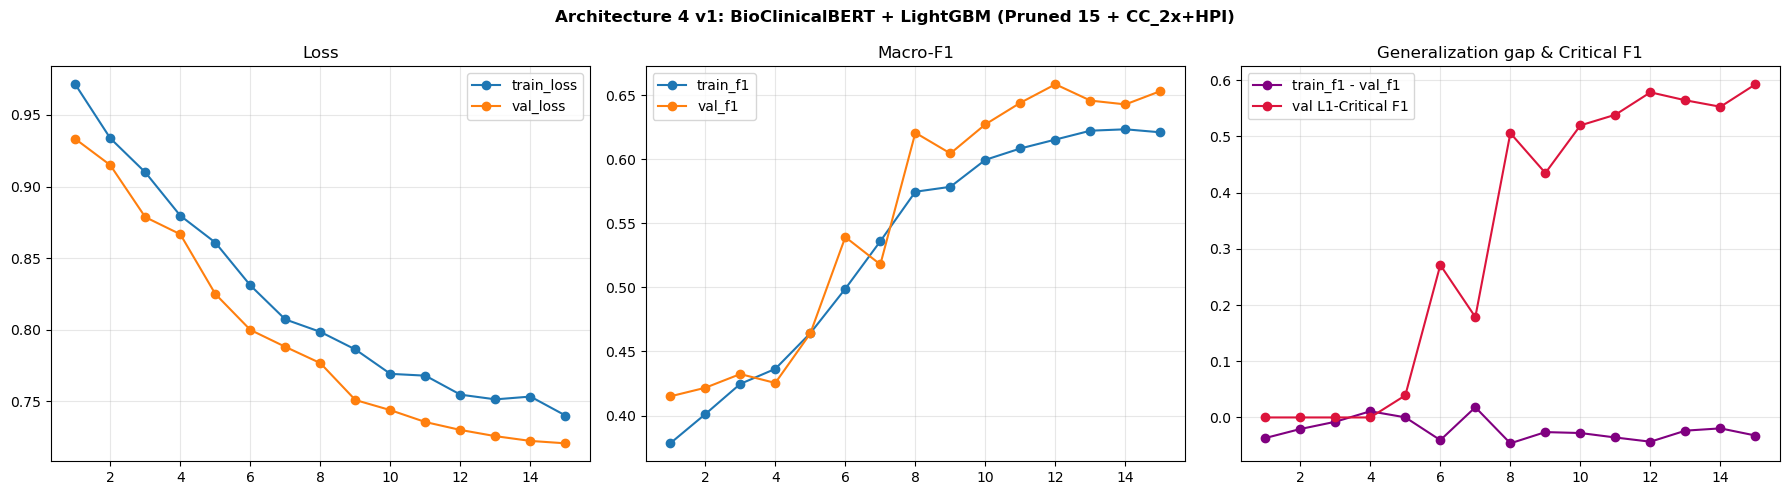

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   marker="o", label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_f1"], marker="o", label="train_f1")
axes[1].plot(history_df["epoch"], history_df["val_f1"],   marker="o", label="val_f1")
axes[1].set_title("Macro-F1")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history_df["epoch"], history_df["generalization_gap"], marker="o",
             color="purple", label="train_f1 - val_f1")
axes[2].plot(history_df["epoch"], history_df["val_critical_f1"],    marker="o",
             color="crimson", label="val L1-Critical F1")
axes[2].set_title("Generalization gap & Critical F1")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Architecture 4 v1: BioClinicalBERT + LightGBM (Pruned 15 + CC_2x+HPI)", fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Evaluation on Test Set

In [16]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

val_metrics      = eval_epoch(model, val_loader,  criterion)
test_metrics     = eval_epoch(model, test_loader, criterion)
all_test_probs   = predict_probs(model, test_loader)

weighted_f1 = f1_score(y_test, test_metrics["preds"], average="weighted")
roc_auc     = roc_auc_score(y_test, all_test_probs, multi_class="ovr", average="macro")

print("Validation macro-F1:  ", round(val_metrics["macro_f1"],  4))
print("Test macro-F1:        ", round(test_metrics["macro_f1"], 4))
print("Validation critical F1:", round(val_metrics["critical_f1"],  4))
print("Test critical F1:      ", round(test_metrics["critical_f1"], 4))
print("Test weighted F1:      ", round(weighted_f1, 4))
print("Test ROC-AUC (OvR):    ", round(roc_auc, 4))
print()

# ── Comparison vs arch1_enhanced baseline ──────────────────────────────────────
ARCH1_BASELINE = {"macro_f1": 0.6277, "critical_f1": 0.5238, "roc_auc": 0.8026}
print("--- vs arch1_enhanced_features baseline ---")
print(f"  macro-F1:     {test_metrics['macro_f1']:.4f} vs {ARCH1_BASELINE['macro_f1']:.4f} "
      f"(delta={test_metrics['macro_f1'] - ARCH1_BASELINE['macro_f1']:+.4f})")
print(f"  critical-F1:  {test_metrics['critical_f1']:.4f} vs {ARCH1_BASELINE['critical_f1']:.4f} "
      f"(delta={test_metrics['critical_f1'] - ARCH1_BASELINE['critical_f1']:+.4f})")
print(f"  ROC-AUC:      {roc_auc:.4f} vs {ARCH1_BASELINE['roc_auc']:.4f} "
      f"(delta={roc_auc - ARCH1_BASELINE['roc_auc']:+.4f})")
print()

print("Classification report:")
print(classification_report(
    y_test, test_metrics["preds"],
    target_names=CLASS_NAMES, zero_division=0
))

summary_df = pd.DataFrame({
    "metric": [
        "val_macro_f1", "test_macro_f1",
        "val_critical_f1", "test_critical_f1",
        "test_weighted_f1", "test_roc_auc_ovr_macro",
    ],
    "value": [
        val_metrics["macro_f1"], test_metrics["macro_f1"],
        val_metrics["critical_f1"], test_metrics["critical_f1"],
        weighted_f1, roc_auc,
    ],
})
summary_df

Validation macro-F1:   0.6585
Test macro-F1:         0.6492
Validation critical F1: 0.5783
Test critical F1:       0.5647
Test weighted F1:       0.7037
Test ROC-AUC (OvR):     0.8231

--- vs arch1_enhanced_features baseline ---
  macro-F1:     0.6492 vs 0.6277 (delta=+0.0215)
  critical-F1:  0.5647 vs 0.5238 (delta=+0.0409)
  ROC-AUC:      0.8231 vs 0.8026 (delta=+0.0205)

Classification report:
                      precision    recall  f1-score   support

         L1-Critical       0.69      0.48      0.56        50
         L2-Emergent       0.62      0.56      0.59       310
L3-Urgent/LessUrgent       0.76      0.83      0.79       479

            accuracy                           0.71       839
           macro avg       0.69      0.62      0.65       839
        weighted avg       0.70      0.71      0.70       839



,metric,value
0,val_macro_f1,0.658455
1,test_macro_f1,0.649186
2,val_critical_f1,0.578313
3,test_critical_f1,0.564706
4,test_weighted_f1,0.703655
5,test_roc_auc_ovr_macro,0.823145


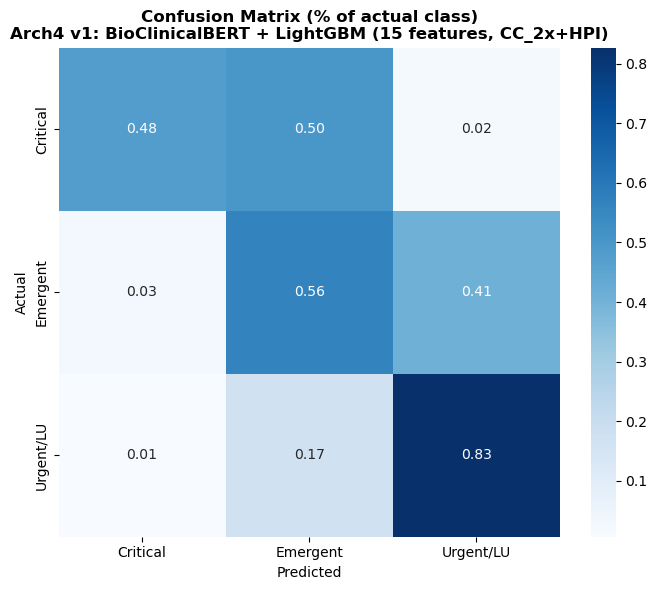


Raw confusion matrix:
                      L1-Critical  L2-Emergent  L3-Urgent/LessUrgent
L1-Critical                    24           25                     1
L2-Emergent                     8          175                   127
L3-Urgent/LessUrgent            3           80                   396


In [17]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm     = confusion_matrix(y_test, test_metrics["preds"], labels=[0, 1, 2])
cm_pct = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_pct, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=["Critical", "Emergent", "Urgent/LU"],
    yticklabels=["Critical", "Emergent", "Urgent/LU"],
)
plt.title(
    "Confusion Matrix (% of actual class)\n"
    "Arch4 v1: BioClinicalBERT + LightGBM (15 features, CC_2x+HPI)",
    fontweight="bold"
)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("\nRaw confusion matrix:")
print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))

## 12. Save Artifacts to S3

In [18]:
def upload_file(local_path, s3_key):
    s3.upload_file(local_path, S3_BUCKET, s3_key)
    print(f"  Uploaded → s3://{S3_BUCKET}/{s3_key}")

print(f"Saving artifacts to s3://{S3_BUCKET}/{MODEL_PREFIX}")

# 1. Fusion model weights
model_path = "/tmp/arch4_v1_best_model.pt"
torch.save(model.state_dict(), model_path)
upload_file(model_path, f"{MODEL_PREFIX}best_model.pt")

# 2. LightGBM fold models
for idx, fold_model in enumerate(lgbm_fold_models, start=1):
    fold_path = f"/tmp/arch4_v1_lgbm_fold{idx}.joblib"
    joblib.dump(fold_model, fold_path)
    upload_file(fold_path, f"{MODEL_PREFIX}lgbm_fold{idx}.joblib")

# 3. Training history
history_path = "/tmp/arch4_v1_history.csv"
history_df.to_csv(history_path, index=False)
upload_file(history_path, f"{MODEL_PREFIX}history.csv")

# 4. LightGBM fold summary
fold_path = "/tmp/arch4_v1_lgbm_fold_summary.csv"
fold_summary.to_csv(fold_path, index=False)
upload_file(fold_path, f"{MODEL_PREFIX}lgbm_fold_summary.csv")

# 5. Config
config = {
    "architecture":        "arch4_v1",
    "description":         "BioClinicalBERT + LightGBM fusion, pruned 15 features, CC_2x+HPI text",
    "structured_features": STRUCTURED_FEATURES,
    "n_features":          len(STRUCTURED_FEATURES),
    "n_classes":           NUM_CLASSES,
    "bert_model":          BERT_MODEL,
    "max_len":             MAX_LEN,
    "tree_model":          "LightGBM",
    "text_format":         "CC_2x + HPI (PMH dropped)",
    "structured_stats":    structured_stats,
    "transport_map":       TRANSPORT_MAP,
    "class_weights":       [float(x) for x in CLASS_WEIGHTS.tolist()],
    "fusion_hidden_dim":   FUSION_HIDDEN_DIM,
    "fusion_dropout":      FUSION_DROPOUT,
    "unfreeze_layers":     UNFREEZE_LAYERS,
    "changes_vs_arch1_enhanced": [
        "LightGBM replaces XGBoost (+3pts macro-F1 in ablation)",
        "Pruned 31→15 structured features (SHAP/permutation importance)",
        "CC_2x+HPI text format (TF-IDF ablation: +0.076 vs +0.054 for CC+HPI+PMH)",
    ],
    "test_metrics": {
        "macro_f1":     round(test_metrics["macro_f1"],  4),
        "critical_f1":  round(test_metrics["critical_f1"], 4),
        "weighted_f1":  round(weighted_f1, 4),
        "roc_auc_ovr":  round(roc_auc, 4),
    },
    "best_val_f1": round(best_val_f1, 4),
}
config_path = "/tmp/arch4_v1_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
upload_file(config_path, f"{MODEL_PREFIX}config.json")

print()
print("All artifacts saved.")
print(f"Config: {json.dumps(config, indent=2)}")

Saving artifacts to s3://ed-triage-capstone-group7/models/arch4_v1/
  Uploaded → s3://ed-triage-capstone-group7/models/arch4_v1/best_model.pt
  Uploaded → s3://ed-triage-capstone-group7/models/arch4_v1/lgbm_fold1.joblib
  Uploaded → s3://ed-triage-capstone-group7/models/arch4_v1/lgbm_fold2.joblib
  Uploaded → s3://ed-triage-capstone-group7/models/arch4_v1/lgbm_fold3.joblib
  Uploaded → s3://ed-triage-capstone-group7/models/arch4_v1/lgbm_fold4.joblib
  Uploaded → s3://ed-triage-capstone-group7/models/arch4_v1/lgbm_fold5.joblib
  Uploaded → s3://ed-triage-capstone-group7/models/arch4_v1/history.csv
  Uploaded → s3://ed-triage-capstone-group7/models/arch4_v1/lgbm_fold_summary.csv
  Uploaded → s3://ed-triage-capstone-group7/models/arch4_v1/config.json

All artifacts saved.
Config: {
  "architecture": "arch4_v1",
  "description": "BioClinicalBERT + LightGBM fusion, pruned 15 features, CC_2x+HPI text",
  "structured_features": [
    "heart_rate",
    "sbp",
    "dbp",
    "resp_rate",
    "s